# Make Combined Estimation File

This similar to the standard Make Estimation file, but it replaces the TNC trips observed in the HH travel survey with the TNC trips observed in the Chicago TNP data.  This is similar to replacing transit trips in a HH survey with those from an onboard transit survey.  It is a choice-based sampling approach that provides for a much larger sample size for trips with small shares that we care about.  


In [97]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')


In [69]:
# start from the survey trips

survey_trips = pd.read_csv('out/mode_choice_estimation_file.csv')
survey_trips.head()

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,mode2,o_district,d_district,o_community,d_community,hh_id_tour,person_id_tour,person_num_tour,day_id_tour,day_num_tour,distance_meters_tour,distance_miles_tour,duration_minutes_tour,o_tract_2020_tour,d_tract_2020_tour,num_travelers,num_hh_travelers,joint_status_tour,tour_num_tour,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight,day_of_week,time_period,origin_id,destination_id,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,transit_avail,walk_avail,transit_or_walk_avail,income_detailed,income_broad,num_vehicles,num_people,num_workers,num_adults,num_kids,hh_weight,income_labeled,tract_2020,hh_share_inc_under_100k,hh_share_inc_over_100k
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,32.0,8.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031320101,17031081500,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,-5.018459,6.707731,1,1,1,12,5,2,2,1,2,0,794.392,"$150,000 or more",17031320101,0.341000,0.659000
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,8.0,8.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031081500,17031081403,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,0.986765,4.798943,1,1,1,12,5,2,2,1,2,0,794.392,"$150,000 or more",17031081500,0.321678,0.678322
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,8.0,32.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031081403,17031320101,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,-0.323012,6.244886,1,1,1,12,5,2,2,1,2,0,794.392,"$150,000 or more",17031081403,0.460539,0.539461
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1,Walk,walk,walk,Downtown,Downtown,32.0,32.0,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15

In [70]:
# and the TNP trips

tnc_trips = pd.read_csv('../data_processing/out/processed_tnp_trips.csv')
tnc_trips.head()

,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Percent Time Chicago,Percent Distance Chicago,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Shared Trip Authorized,Shared Trip Match,Trips Pooled,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location,time_period,Inferred Pickup Census Tract (time),Inferred Dropoff Census Tract (time),Pickup district,Dropoff district,congested_car_time_min,fftime,calc_fare,transit_time,walk_time,Pickup hh_share_inc_under_100k,Pickup hh_share_inc_over_100k,Dropoff hh_share_inc_under_100k,Dropoff hh_share_inc_over_100k
0,f5045620992c5bb5cac200d5db51fbc9d1e980dc,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,396,1.0,99%,98%,1.703108e+10,1.703132e+10,8,32,$7.5,$0,$3.41,$10.91,False,False,1,41.892073,-87.628874,POINT (-87.6288741572 41.8920726347),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918),night,17031081600,17031320100,Downtown,NaN,NaN,NaN,7.075723,NaN,20.0,0.319000,0.681000,NaN,NaN
1,f5189089ccfbbde63cc147ad6c15a35b7d3acb89,04/16/2025 11:45:00 PM,04/16/2025 11:45:00 PM,737,2.9,100%,100%,1.703106e+10,1.703103e+10,6,77,$5,$3,$3.13,$11.13,False,False,1,41.950673,-87.666536,POINT (-87.6665362813 41.9506733576),41.987226,-87.664938,POINT (-87.6649377243 41.9872255578),night,17031060400,17031030500,Other,Other,8.266137,6.941667,11.255542,75.0,58.0,0.267000,0.733000,0.348303,0.651697
2,f53b28d0530f1e3657d0741e2cf98574a3683b75,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,310,1.5,100%,100%,NaN,NaN,41,39,$7.5,$0,$2.31,$9.81,False,False,1,41.794090,-87.592311,POINT (-87.592310855 41.794090253),41.808916,-87.596183,POINT (-87.5961833442 41.8089162826),night,17031411100,17031390500,Other,Other,5.166087,4.338333,6.908713,40.0,30.0,0.426573,0.573427,0.594595,0.405405
3,f55bc6fbaee328d0ee6108316cb12daf270099b9,04/16/2025 11:45:00 PM,04/17/2025 12:15:00 AM,1243,8.8,100%,100%,NaN,NaN,4,33,$12.5,$0,$3.33,$15.83,False,False,1,41.975171,-87.687516,POINT (-87.6875155152 41.9751709433),41.857184,-87.620335,POINT (-87.6203346241 41.8571838585),night,17031040100,17031330200,Other,Other,20.717935,17.398333,20.248924,999.0,176.0,0.551000,0.449000,0.304695,0.695305
4,f56a5b36e42c9067ddf4ac0a40a9fb568034eb30,04/16/2025 11:45:00 PM,04/17/2025 12:00:00 AM,314,1.5,100%,100%,NaN,NaN,31,28,$7.5,$0,$1.23,$8.73,False,False,1,41.850266,-87.667569,POINT (-87.667569312 41.8502663663),41.874005,-87.663518,POINT (-87.6635175498 41.874005383),night,17031843200,17031832900,Other,Other,5.243489,4.403333,6.937551,49.0,30.0,0.567000,0.433000,0.585000,0.415000


In [71]:
# keep only the relevant fields
survey_trips = survey_trips[[
    'hh_id',
    'person_id',
    'person_num',
    'day_id',
    'day_num',
    'depart_date',
    'o_tract_2020',
    'd_tract_2020',
    'linked_trip_id',
    'linked_trip_num',
    'linked_trip_mode',
    'linked_trip_weight',
    'linked_trip_mode_labeled',
    'mode',
    'mode2',
    'distance_miles', 
    'duration_minutes', 
    'o_district',
    'd_district',
    'o_community',
    'd_community',
    'time_period',
    'ff_car_time_minutes',
    'car_ivt',
    'tnc_wait',
    'tnc_time',
    'tnc_fare',
    'transit_fare',
    'walk_time',
    'transit_time',
    'transit_or_walk_time',
    'walk_faster_than_transit',
    'transit_or_walk_fare',
    'income_broad',
    'income_labeled',
    'hh_share_inc_under_100k',
    'hh_share_inc_over_100k'
    ]]


In [72]:
# keep only the relevant fields in the TNP file
tnc_trips = tnc_trips[[
    'Trip ID',
    'Trip Seconds',
    'Trip Miles',
    'Fare',
    'Tip',
    'Additional Charges',
    'time_period',
    'Pickup district', 
    'Dropoff district', 
    'Pickup Community Area', 
    'Dropoff Community Area', 
    'Inferred Pickup Census Tract (time)',
    'Inferred Dropoff Census Tract (time)',
    'fftime', 
    'congested_car_time_min',
    'calc_fare',
    'transit_time',
    'walk_time',
    'Pickup hh_share_inc_under_100k',
    'Pickup hh_share_inc_over_100k'
    ]]



In [73]:
# align the columns such that key fields have the same names

tnc_trips = tnc_trips.rename(columns = {'Trip ID' : 'tnc_trip_id', 
                                        'Fare' : 'obs_fare', 
                                        'Tip' : 'obs_tip', 
                                        'Additional Charges' : 'obs_additional_charges', 
                                        'Trip Miles' : 'distance_miles', 
                                        'Trip Seconds' : 'duration_seconds',                  
                                        'Pickup district' : 'o_district', 
                                        'Dropoff district' : 'd_district',            
                                        'Pickup Community Area' : 'o_community', 
                                        'Dropoff Community Area' : 'd_community', 
                                        'Inferred Pickup Census Tract (time)' : 'o_tract_2020',
                                        'Inferred Dropoff Census Tract (time)' : 'd_tract_2020',
                                        'fftime' : 'ff_car_time_minutes',
                                        'congested_car_time_min' : 'car_ivt',
                                        'calc_fare' : 'tnc_fare',
                                        'Pickup hh_share_inc_under_100k': 'hh_share_inc_under_100k',
                                        'Pickup hh_share_inc_over_100k' : 'hh_share_inc_over_100k'
                                        })

In [74]:
# calculate additional columns for better alignment

tnc_trips['duration_minutes'] = tnc_trips['duration_seconds'] / 60
tnc_trips = tnc_trips.drop(columns=['duration_seconds'])

tnc_trips['mode'] = 'tnc'
tnc_trips['mode2'] = 'tnc'
tnc_trips['tnc_wait'] = 5
tnc_trips['tnc_time'] = tnc_trips['tnc_wait'] + tnc_trips['car_ivt']
tnc_trips['transit_fare'] = 2.5
tnc_trips['linked_trip_weight'] = 1.0



In [75]:
# convert observed fares to numerical columns
for col in ['obs_fare', 'obs_tip', 'obs_additional_charges']:
    tnc_trips[col] = (
        tnc_trips[col]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )


In [76]:
# drop the TNC trips from the HH survey and combine the files
survey_trips = survey_trips[survey_trips['mode'] != 'tnc'].copy()
combined_trips = pd.concat([survey_trips, tnc_trips], ignore_index=True)
combined_trips

,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges
0,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031081500,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.810270,20.000000,Downtown,Downtown,32.0,8.0,midday,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,NaN,NaN,NaN,NaN
1,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081500,17031081403,2.400012e+15,2.0,15.0,1853.792592,Walk,walk,walk,0.338027,28.000000,Downtown,Downtown,8.0,8.0,midday,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,5.0,"$150,000 or more",0.321678,0.678322,NaN,NaN,NaN,NaN
2,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081403,17031320101,2.400012e+15,3.0,15.0,1853.792592,Walk,walk,walk,0.549293,15.000000,Downtown,Downtown,8.0,32.0,midday,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,5.0,"$150,000 or more",0.460539,0.539461,NaN,NaN,NaN,NaN
3,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320101,2.400012e+15,4.0,15.0,1853.792592,Walk,walk,walk,0.319386,16.000000,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.167457,2.5,6.387712,12.0,6.387712,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,NaN,NaN,NaN,NaN
4,24000124.0,2.400012e+09,2.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320102,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.751861,16.000000,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.561010,2.5,15.037220,12.0,12.000000,False,2.5,5.0,"$150,000 or more",0.341000,0.659000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188180,NaN,NaN,NaN,NaN,NaN,NaN,17031839000,17031071600,NaN,NaN,NaN,1.000000,NaN,tnc,tnc,3.400000,10.116667,Downtown,Other,32.0,7.0,night,8.488333,10.107907,5,15.107907,10.771317,2.5,68.000000,95.0,NaN,NaN,NaN,NaN,NaN,0.485000,0.515000,19d5bdd87861afc50be6e60d86bb6162eab1d37f,27.5,0.0,3.55
188181,NaN,NaN,NaN,NaN,NaN,NaN,17031831500,17031190100,NaN,NaN,NaN,1.000000,NaN,tnc,tnc,2.300000,10.783333,Other,Other,19.0,19.0,night,8.048333,9.583955,5,14.583955,10.063092,2.5,46.000000,74.0,NaN,NaN,NaN,NaN,NaN,0.567000,0.433000,19e320f52f745a31fb9e936bb81054ff717a18f9,5.0,0.0,1.45
188182,NaN,NaN,NaN,NaN,NaN,NaN,17031330101,17031430200,NaN,NaN,NaN,1.000000,NaN,tnc,tnc,8.500000,15.766667,Tourist,Other,33.0,43.0,night,13.246667,15.774131,5,20.774131,17.835923,2.5,170.000000,999.0,NaN,NaN,NaN,NaN,NaN,0.197605,0.802395,1a450fa5be8973044470459fb0996f917539193c,15.0,0.0,3.63
188183,NaN,NaN,NaN,NaN,NaN,NaN,17031460400,17031710600,NaN,NaN,NaN,1.000000,NaN,tnc,tnc,5.400000,19.316667,Other,Other,46.0,71.0,night,11.526667,13.725955,5,18.725955,16.562925,2.5,108.000000,147.0,NaN,NaN,NaN,NaN,NaN,0.715431,0.284569,1acd6586d7fa041e6f6ba72c92ce334848422db5,15.0,0.0,1.23


In [77]:
# calculated fields for binary choice

# determine the faster of the walk or transit time for each trip
combined_trips['transit_or_walk_time'] = combined_trips[['transit_time', 'walk_time']].min(axis=1)

# note whether transit or walk is faster
combined_trips['walk_faster_than_transit'] = combined_trips['walk_time'] < combined_trips['transit_time']

# if walk is faster, set the transit_or_walk_fare to zero
combined_trips['transit_or_walk_fare'] = np.where(combined_trips['walk_faster_than_transit'], 0, combined_trips['transit_fare'])


# Filter records

Exclude records where there are illogical results. 

In [78]:
# Keep only trips in Chicago

trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['o_district'] != 'External') & (combined_trips['d_district'] != 'External') ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 188185 After: 188139


In [79]:
# drop trips where the calculated transit time is missing.  These seem to be trips that go out of state
# and where we didn't calculate paths. 

trips_before = len(combined_trips)
combined_trips = combined_trips[combined_trips['transit_time'].notna()].copy()
print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 188139 After: 174805


In [92]:
# next we filter to exclude trips we don't have in our TNC data.
# We could re-consider whether to drop the airport trips.  It's not obvious it's necessary to drop them, but there are not many here. 

trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['o_district'] != 'Airport') & (combined_trips['d_district'] != 'Airport') ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174309 After: 161445


In [80]:
# drop if distance is crazy short

trips_before = len(combined_trips)
combined_trips = combined_trips[combined_trips['distance_miles']>0.1].copy()

print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174805 After: 174641


In [81]:
# drop if distance is crazy long

trips_before = len(combined_trips)
combined_trips = combined_trips[combined_trips['distance_miles']<50].copy()

print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174641 After: 174636


In [82]:
# drop if time is crazy short

trips_before = len(combined_trips)
combined_trips = combined_trips[combined_trips['duration_minutes']>1].copy()

print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174636 After: 174443


In [83]:
# drop if time is crazy long

trips_before = len(combined_trips)
combined_trips = combined_trips[combined_trips['duration_minutes']<180].copy()

print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174443 After: 174381


In [84]:
# drop if observed fare is crazy high

trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['obs_fare']<100) | (combined_trips['obs_fare'].isna())].copy()

print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174381 After: 174313


In [85]:
# drop if observed additional charges are crazy high

trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['obs_additional_charges']<100) | (combined_trips['obs_fare'].isna())].copy()

print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174313 After: 174309


In [86]:
# set availability rules for transit

# transit is not available if the router can't find a path
combined_trips['transit_avail'] = np.where(combined_trips['transit_time']<999, 1, 0)

# drop trips that choose an unavailable alternative
trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['transit_avail']==1) | (combined_trips['mode']!='transit')].copy()
print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174309 After: 174309


In [87]:
# set availability rules for walk

# walk is not avaiable if it would take more than 1 hour to walk
combined_trips['walk_avail'] = np.where(combined_trips['walk_time']<60, 1, 0)

# drop trips that choose an unavailable alternative
trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['walk_avail']==1) | (combined_trips['mode']!='walk')].copy()
print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 174309 After: 174309


In [100]:
# set availability rules for transit or walk

combined_trips['transit_or_walk_avail'] = combined_trips[['transit_avail', 'walk_avail']].max(axis=1)

# drop trips that choose an unavailable alternative
trips_before = len(combined_trips)
combined_trips = combined_trips[(combined_trips['transit_or_walk_avail']==1) | (combined_trips['mode']=='tnc')].copy()
print("Before: " + str(trips_before) + " After: " + str(len(combined_trips)))

Before: 161445 After: 161445


# Summarize the data

In [93]:
combined_trips.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,hh_id,person_id,person_num,day_id,day_num,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,distance_miles,duration_minutes,o_community,d_community,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,transit_or_walk_fare,income_broad,hh_share_inc_under_100k,hh_share_inc_over_100k,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,5.099000e+03,5.099000e+03,5099.000000,5.099000e+03,5099.000000,1.614450e+05,1.614450e+05,5.099000e+03,5099.000000,5099.000000,161445.000000,161445.000000,161445.000000,161445.000000,161445.000000,161445.000000,161445.000000,161445.0,161445.000000,161445.000000,161445.0,161445.000000,161445.000000,161445.000000,161445.000000,5099.000000,161301.000000,161301.000000,156139.000000,156139.000000,156139.000000,161445.000000,161445.000000,161445.000000,161445.000000
mean,2.407447e+07,2.407447e+09,1.396352,2.407447e+11,2.907041,1.703139e+10,1.703140e+10,2.407447e+15,1.943518,12.300255,17.102609,4.356122,16.035119,27.293276,27.621592,8.127118,13.647502,5.0,18.647502,13.986703,2.5,87.122442,78.465577,48.367103,1.833999,45.116297,0.537077,0.462923,13.306765,0.782623,3.807463,0.965028,0.482214,-29.719601,12.152704
std,6.277273e+04,6.277273e+06,0.822398,6.277273e+08,2.178299,3.097775e+05,3.121163e+05,6.277273e+12,1.328958,4.057823,229.311143,3.882085,11.179261,20.096745,20.139556,5.419174,9.278023,0.0,9.278023,7.643080,0.0,77.641705,177.250334,45.006219,1.105193,200.161399,0.204123,0.204123,7.756987,1.869551,2.843110,0.183709,0.499685,41.084474,7.406947
min,2.400012e+07,2.400012e+09,1.000000,2.400012e+11,1.000000,1.703101e+10,1.703101e+10,2.400012e+15,1.000000,3.000000,0.000000,0.100041,1.016667,1.000000,1.000000,0.000000,0.000000,5.0,5.000000,3.709778,2.5,2.000820,4.000000,2.000820,0.000000,1.000000,0.134000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-755.930043,1.324759
1%,2.400216e+07,2.400216e+09,1.000000,2.400216e+11,1.000000,1.703101e+10,1.703101e+10,2.400216e+15,1.000000,3.000000,0.000000,0.338648,2.666667,1.000000,1.000000,0.000000,0.000000,5.0,5.000000,4.789594,2.5,6.772963,9.000000,6.000000,0.000000,1.000000,0.202000,0.051000,2.500000,0.000000,1.170000,0.000000,0.000000,-239.704143,3.136420
5%,2.401379e+07,2.401379e+09,1.000000,2.401379e+11,1.000000,1.703103e+10,1.703103e+10,2.401379e+15,1.000000,6.000000,1.000000,0.700000,4.266667,4.000000,4.000000,2.045000,3.318275,5.0,8.318275,5.726687,2.5,14.000000,15.000000,12.000000,0.000000,1.000000,0.260521,0.115115,5.000000,0.000000,1.230000,1.000000,0.000000,-89.830219,4.512768
50%,2.407244e+07,2.407244e+09,1.000000,2.407244e+11,2.000000,1.703128e+10,1.703129e+10,2.407244e+15,2.000000,15.000000,1.000000,3.100000,13.250000,26.000000,28.000000,6.776667,11.333166,5.0,16.333166,11.932263,2.5,62.000000,40.000000,38.000000,2.500000,3.000000,0.521000,0.479000,12.500000,0.000000,2.960000,1.000000,0.000000,-20.520820,9.914817
95%,2.414789e+07,2.414789e+09,3.000000,2.414789e+11,7.000000,1.703184e+10,1.703184e+10,2.414789e+15,4.000000,15.000000,1.000000,12.300000,37.183333,70.000000,71.000000,18.771667,31.659047,5.0,36.659047,28.938849,2.5,246.000000,143.000000,111.000000,2.500000,5.000000,0.884885,0.739479,27.500000,5.000000,8.940000,1.000000,1.000000,-3.332699,26.917303
99%,2.420859e+07,2.420859e+09,4.000000,2.420859e+11,7.000000,1.703184e+10,1.703184e+10,2.420859e+15,6.000000,15.000000,252.000765,17.800000,55.268667,77.000000,77.000000,25.056667,43.816245,5.0,48.816245,39.334850,2.5,356.000000,999.000000,268.000000,2.500000,999.000000,0.949000,0.798000,40.000000,8.000000,13.830000,1.000000,1.000000,2.109786,37.100928
max,2.460116e+07,2.460116e+09,10.000000,2.460116e+11,7.000000,1.703184e+10,1.703184e+10,2.460116e+15,26.000000,18.000000,13997.884032,48.400000,178.000000,77.000000,77.000000,46.965000,92.891601,5.0,97.891601,88.642819,2.5,968.000000,999.000000,792.000000,2.500000,999.

In [94]:
# calculate the time and cost differences for TNC vs transit/walk
combined_trips['tnc_time_minus_transit_walk'] = combined_trips['tnc_time'] - combined_trips['transit_or_walk_time']
combined_trips['tnc_cost_minus_transit_walk'] = combined_trips['tnc_fare'] - combined_trips['transit_or_walk_fare']

In [ ]:
print('All Trips')
display(combined_trips[['distance_miles', 
                     'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
                     'transit_or_walk_time', 'transit_or_walk_fare', 
                     'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk', 
                     'transit_avail', 'walk_avail'
                     ]].describe(percentiles=[0.05, 0.5, 0.95]).style.format('{:.1f}'))

print('\nTNC Trips')
tnc = combined_trips[combined_trips['mode']=='tnc']
display(tnc[['distance_miles', 
             'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
             'transit_or_walk_time', 'transit_or_walk_fare', 
             'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
             ]].describe(percentiles=[0.05, 0.5, 0.95]).style.format('{:.1f}'))

print('\nTransit Trips')
transit = combined_trips[combined_trips['mode']=='transit']
display(transit[['distance_miles', 
                 'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
                 'transit_or_walk_time', 'transit_or_walk_fare', 
                 'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
                 ]].describe(percentiles=[0.05, 0.5, 0.95]).style.format('{:.1f}'))

print('\nWalk Trips')
walk = combined_trips[combined_trips['mode']=='walk']
display(walk[['distance_miles', 'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
              'transit_or_walk_time', 'transit_or_walk_fare', 
              'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
              ]].describe(percentiles=[0.05, 0.5, 0.95]).style.format('{:.1f}'))


All Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,161445.0,161445.0,161445.0,161445.0,161445.0,161445.0,161445.0,161445.0,161445.0,161445.0
mean,4.4,18.6,14.0,87.1,78.5,2.5,48.4,1.8,-29.7,12.2
std,3.9,9.3,7.6,77.6,177.3,0.0,45.0,1.1,41.1,7.4
min,0.1,5.0,3.7,2.0,4.0,2.5,2.0,0.0,-755.9,1.3
5%,0.7,8.3,5.7,14.0,15.0,2.5,12.0,0.0,-89.8,4.5
50%,3.1,16.3,11.9,62.0,40.0,2.5,38.0,2.5,-20.5,9.9
95%,12.3,36.7,28.9,246.0,143.0,2.5,111.0,2.5,-3.3,26.9
max,48.4,97.9,88.6,968.0,999.0,2.5,792.0,2.5,24.6,86.1



TNC Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,156346.0,156346.0,156346.0,156346.0,156346.0,156346.0,156346.0,156346.0,156346.0,156346.0
mean,4.4,18.8,14.2,88.7,80.2,2.5,49.3,1.9,-30.5,12.3
std,3.9,9.3,7.6,77.8,179.8,0.0,45.3,1.1,41.5,7.4
min,0.2,5.0,3.9,4.0,4.0,2.5,4.0,0.0,-755.9,1.8
5%,0.8,8.5,5.9,16.0,16.0,2.5,14.0,0.0,-92.4,4.6
50%,3.2,16.5,12.1,64.0,40.0,2.5,39.0,2.5,-20.9,10.1
95%,12.4,36.8,29.1,248.0,146.0,2.5,114.0,2.5,-4.6,27.1
max,48.4,97.9,88.6,968.0,999.0,2.5,792.0,2.5,24.6,86.1



Transit Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,1583.0,1583.0,1583.0,1583.0,1583.0,1583.0,1583.0,1583.0,1583.0,1583.0
mean,4.9,22.2,15.2,98.8,43.3,2.5,42.2,2.2,-20.1,13.0
std,3.3,9.5,6.9,66.5,17.7,0.0,17.1,0.8,11.9,6.6
min,0.1,6.6,4.3,2.7,5.0,2.5,2.7,0.0,-124.0,1.8
5%,0.9,9.7,6.3,18.1,20.0,2.5,16.3,0.0,-36.8,5.0
50%,4.4,21.1,14.4,88.3,42.0,2.5,41.0,2.5,-19.1,12.0
95%,10.7,39.1,27.9,214.7,72.0,2.5,71.0,2.5,-4.4,25.4
max,33.7,82.1,50.2,673.2,175.0,2.5,145.0,2.5,11.1,47.7



Walk Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,3516.0,3516.0,3516.0,3516.0,3516.0,3516.0,3516.0,3516.0,3516.0,3516.0
mean,0.6,9.3,5.7,11.7,17.0,2.5,10.6,0.5,-1.3,5.2
std,0.4,2.2,1.2,8.9,7.8,0.0,7.0,1.0,6.0,1.4
min,0.1,5.6,3.7,2.0,4.0,2.5,2.0,0.0,-33.9,1.3
5%,0.2,6.8,4.4,3.3,6.0,2.5,3.3,0.0,-12.9,2.5
50%,0.4,8.8,5.4,9.0,16.0,2.5,8.6,0.0,0.2,5.2
95%,1.5,13.4,8.0,29.7,31.0,2.5,24.0,2.5,5.5,7.4
max,3.0,27.0,14.5,59.9,64.0,2.5,50.0,2.5,16.4,12.0


In [96]:
# print both the absolute totals and the mode shares

# TNC
tnc = combined_trips[combined_trips['mode']=='tnc']
print('TNC Trips - Observations')
display(pd.crosstab(tnc['o_district'], tnc['d_district'], margins=True).style.format('{:,.0f}'))

print('TNC Trips - Weighted & Expanded')
tnc_crosstab = pd.crosstab(tnc['o_district'], tnc['d_district'], values=tnc['linked_trip_weight'], aggfunc='sum', margins=True)
display(tnc_crosstab.style.format('{:,.0f}'))

# Transit
transit = combined_trips[combined_trips['mode']=='transit']
print('Transit Trips - Observations')
display(pd.crosstab(transit['o_district'], transit['d_district'], margins=True).style.format('{:,.0f}'))

print('Transit Trips - Weighted & Expanded')
transit_crosstab = pd.crosstab(transit['o_district'], transit['d_district'], values=transit['linked_trip_weight'], aggfunc='sum', margins=True)
display(transit_crosstab.style.format('{:,.0f}'))

# Walk
walk = combined_trips[(combined_trips['mode']=='walk')]
print('Walk Trips - Observations')
display(pd.crosstab(walk['o_district'], walk['d_district'], margins=True).style.format('{:,.0f}'))

print('Walk Trips - Weighted & Expanded')
walk_crosstab = pd.crosstab(walk['o_district'], walk['d_district'], values=walk['linked_trip_weight'], aggfunc='sum', margins=True)
display(walk_crosstab.style.format('{:,.0f}'))


# now print the mode shares with the updated walk, excluding both <0.5 miles and loops
total_crosstab = tnc_crosstab + transit_crosstab + walk_crosstab
tnc_share = tnc_crosstab / total_crosstab
transit_share = transit_crosstab / total_crosstab
walk_share = walk_crosstab / total_crosstab

print('TNC Mode Share')
display(tnc_share.style.format('{:.1%}'))

print('Transit Mode Share')
display(transit_share.style.format('{:.1%}'))

print('Walk Mode Share')
display(walk_share.style.format('{:.1%}'))

TNC Trips - Observations


d_district,Downtown,Other,Tourist,All
o_district,,,,
Downtown,"26,933","19,169",428,"46,530"
Other,"21,057","86,830",509,"108,396"
Tourist,514,902,4,"1,420"
All,"48,504","106,901",941,"156,346"


TNC Trips - Weighted & Expanded


d_district,Downtown,Other,Tourist,All
o_district,,,,
Downtown,"26,933","19,169",428,"46,530"
Other,"21,057","86,830",509,"108,396"
Tourist,514,902,4,"1,420"
All,"48,504","106,901",941,"156,346"


Transit Trips - Observations


...

d_district,Downtown,Other,Tourist,All
o_district,,,,
Downtown,5.7%,7.6%,7.8%,6.4%
Other,7.1%,5.1%,nan%,5.4%
Tourist,8.8%,7.5%,nan%,7.3%
All,6.3%,5.4%,11.0%,5.7%


Transit Mode Share


d_district,Downtown,Other,Tourist,All
o_district,,,,
Downtown,21.6%,73.1%,22.8%,39.5%
Other,80.3%,29.1%,nan%,36.7%
Tourist,20.3%,80.2%,nan%,55.7%
All,44.2%,35.1%,25.6%,37.6%


Walk Mode Share


d_district,Downtown,Other,Tourist,All
o_district,,,,
Downtown,72.7%,19.3%,69.5%,54.1%
Other,12.6%,65.8%,nan%,57.9%
Tourist,70.9%,12.4%,nan%,37.0%
All,49.6%,59.5%,63.4%,56.8%


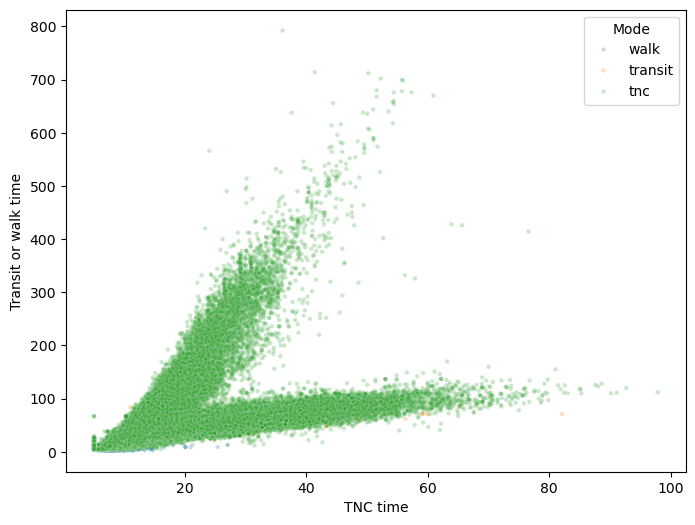

In [98]:
# some scatterplots

plt.figure(figsize=(8, 6))
sns.scatterplot(data=combined_trips, x='tnc_time', y='transit_or_walk_time', hue='mode', alpha=0.25, s=10)
plt.xlabel('TNC time')
plt.ylabel('Transit or walk time')
plt.legend(title='Mode')
plt.show()

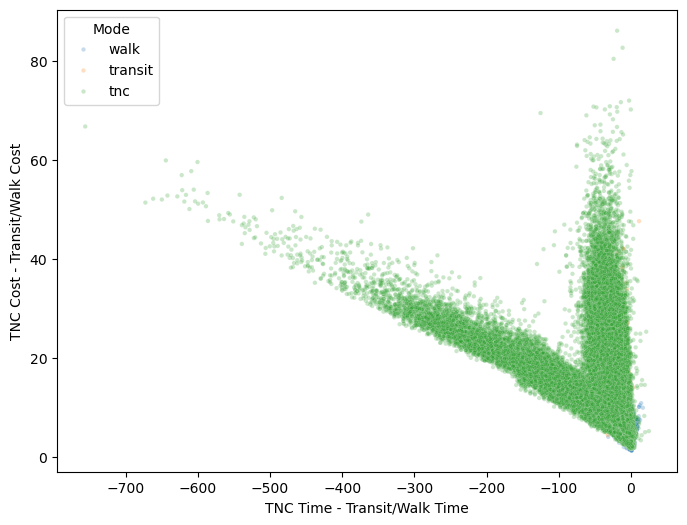

In [99]:
# some scatterplots

plt.figure(figsize=(8, 6))
sns.scatterplot(data=combined_trips, x='tnc_time_minus_transit_walk', y='tnc_cost_minus_transit_walk', hue='mode', alpha=0.25, s=10)
plt.xlabel('TNC Time - Transit/Walk Time')
plt.ylabel('TNC Cost - Transit/Walk Cost')
plt.legend(title='Mode')
plt.show()

I'm not sure why the graphs look like that, but I can dig in later.  

# write the output

In [101]:
combined_trips.to_csv('out/combined_estimation_file.csv')